In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/umarkhan360/lab-2/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

In [3]:
path = '/kaggle/input/datasets/umarkhan360/lab-2/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(path)
# TotalCharges is stored as text; 11 rows are blank (all have tenure = 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print(df.shape, '| missing values:', df.isnull().sum().sum())

(7043, 21) | missing values: 0


In [4]:
def build_features(data):
    """Drop ID and target, one-hot encode every text column."""
    X = data.drop(columns=['customerID', 'Churn'])
    X = pd.get_dummies(X, drop_first=True).astype(float)
    return X
y = (df['Churn'] == 'Yes').astype(int)
X = build_features(df)
print(X.shape)   # expect (7043, 30)

(7043, 30)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)} rows, churn rate {y_train.mean():.3f}')
print(f'Test:  {len(X_test)} rows, churn rate {y_test.mean():.3f}')

Train: 5634 rows, churn rate 0.265
Test:  1409 rows, churn rate 0.265


In [6]:
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
print('Baseline accuracy:', accuracy_score(y_test, dummy.predict(X_test)))

Baseline accuracy: 0.7345635202271115


In [7]:
lr = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)                 # 0 or 1
y_prob_lr = lr.predict_proba(X_test)[:, 1]     # P(churn)
print(classification_report(y_test, y_pred_lr, digits=3))

              precision    recall  f1-score   support

           0      0.851     0.894     0.872      1035
           1      0.658     0.567     0.609       374

    accuracy                          0.807      1409
   macro avg      0.755     0.730     0.741      1409
weighted avg      0.800     0.807     0.802      1409



In [8]:
w = lr.named_steps['model'].coef_[0]
coef = pd.DataFrame({'feature': X.columns,
                     'weight': w,
                     'odds_ratio': np.exp(w)}).sort_values('weight')
print('Most protective:')
print(coef.head(5).round(3).to_string(index=False))
print('\nHighest risk:')
print(coef.tail(5).round(3).to_string(index=False))

Most protective:
           feature  weight  odds_ratio
            tenure  -1.220       0.295
    MonthlyCharges  -0.921       0.398
 Contract_Two year  -0.589       0.555
 Contract_One year  -0.286       0.751
OnlineSecurity_Yes  -0.123       0.884

Highest risk:
                    feature  weight  odds_ratio
          MultipleLines_Yes   0.216       1.242
            StreamingTV_Yes   0.258       1.294
        StreamingMovies_Yes   0.259       1.295
               TotalCharges   0.497       1.644
InternetService_Fiber optic   0.779       2.179


In [9]:
scaler = lr.named_steps['scale']
model = lr.named_steps['model']
x0 = scaler.transform(X_test.iloc[[0]])            # one customer, scaled
z = model.intercept_[0] + (x0 @ model.coef_[0])[0] # linear score
p = 1 / (1 + np.exp(-z))                           # sigmoid
print(f'z = {z:.3f}   sigmoid(z) = {p:.4f}   sklearn = {y_prob_lr[0]:.4f}')

z = -3.070   sigmoid(z) = 0.0444   sklearn = 0.0444


TN=925  FP=110  FN=162  TP=212
By hand : P=0.658  R=0.567  F1=0.609
sklearn : P=0.658  R=0.567  F1=0.609


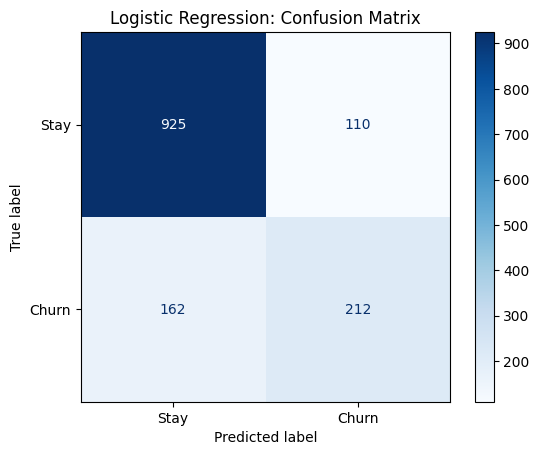

In [10]:
cm = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)
print(f'By hand : P={precision:.3f}  R={recall:.3f}  F1={f1:.3f}')
print(f'sklearn : P={precision_score(y_test, y_pred_lr):.3f}  '
      f'R={recall_score(y_test, y_pred_lr):.3f}  '
      f'F1={f1_score(y_test, y_pred_lr):.3f}')
ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Churn']).plot(cmap='Blues')
plt.title('Logistic Regression: Confusion Matrix')
plt.show()

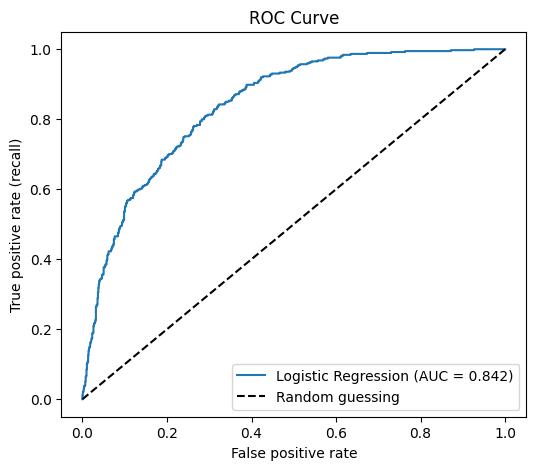

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate (recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [12]:
rows = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (y_prob_lr >= t).astype(int)
    rows.append({'threshold': t,
                 'flagged': int(pred.sum()),
                 'precision': precision_score(y_test, pred),
                 'recall': recall_score(y_test, pred),
                 'f1': f1_score(y_test, pred)})
print(pd.DataFrame(rows).round(3).to_string(index=False))

 threshold  flagged  precision  recall    f1
       0.2      685      0.467   0.856 0.604
       0.3      544      0.518   0.754 0.614
       0.4      441      0.567   0.668 0.613
       0.5      322      0.658   0.567 0.609
       0.6      210      0.710   0.398 0.510
       0.7       89      0.730   0.174 0.281


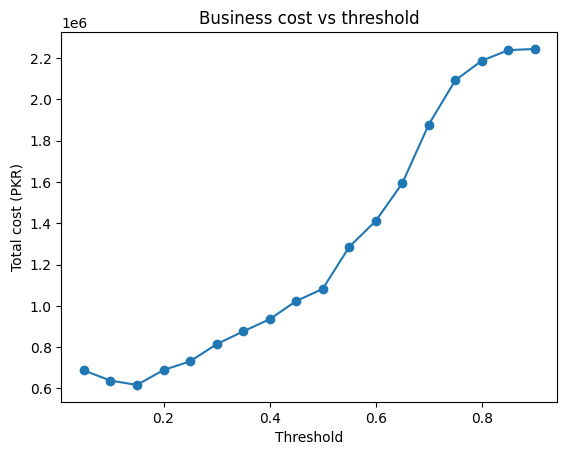

Theory t* = 0.14   Empirical best = 0.15


In [13]:
C_FN, C_FP = 6000, 1000     # PKR: missed churner vs unneeded retention offer
def total_cost(t):
    pred = (y_prob_lr >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return fn * C_FN + fp * C_FP
ts = np.arange(0.05, 0.95, 0.05)
costs = [total_cost(t) for t in ts]
best_t = ts[int(np.argmin(costs))]
plt.plot(ts, costs, marker='o')
plt.xlabel('Threshold'); plt.ylabel('Total cost (PKR)')
plt.title('Business cost vs threshold'); plt.show()
print(f'Theory t* = {C_FP / (C_FP + C_FN):.2f}   Empirical best = {best_t:.2f}')

max_depth  train  test
        1  0.735 0.735
        2  0.791 0.787
        3  0.791 0.787
        4  0.793 0.796
        5  0.801 0.794
        6  0.807 0.797
        8  0.835 0.780
       10  0.872 0.756
       15  0.969 0.737
     None  0.998 0.742


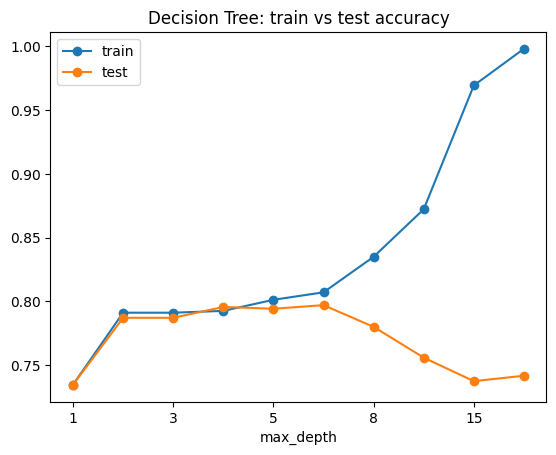

In [14]:
rows = []
for d in [1, 2, 3, 4, 5, 6, 8, 10, 15, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    rows.append({'max_depth': str(d),
                 'train': dt.score(X_train, y_train),
                 'test': dt.score(X_test, y_test)})
depth_df = pd.DataFrame(rows)
print(depth_df.round(3).to_string(index=False))
depth_df.plot(x='max_depth', y=['train', 'test'], marker='o',
              title='Decision Tree: train vs test accuracy')
plt.show()

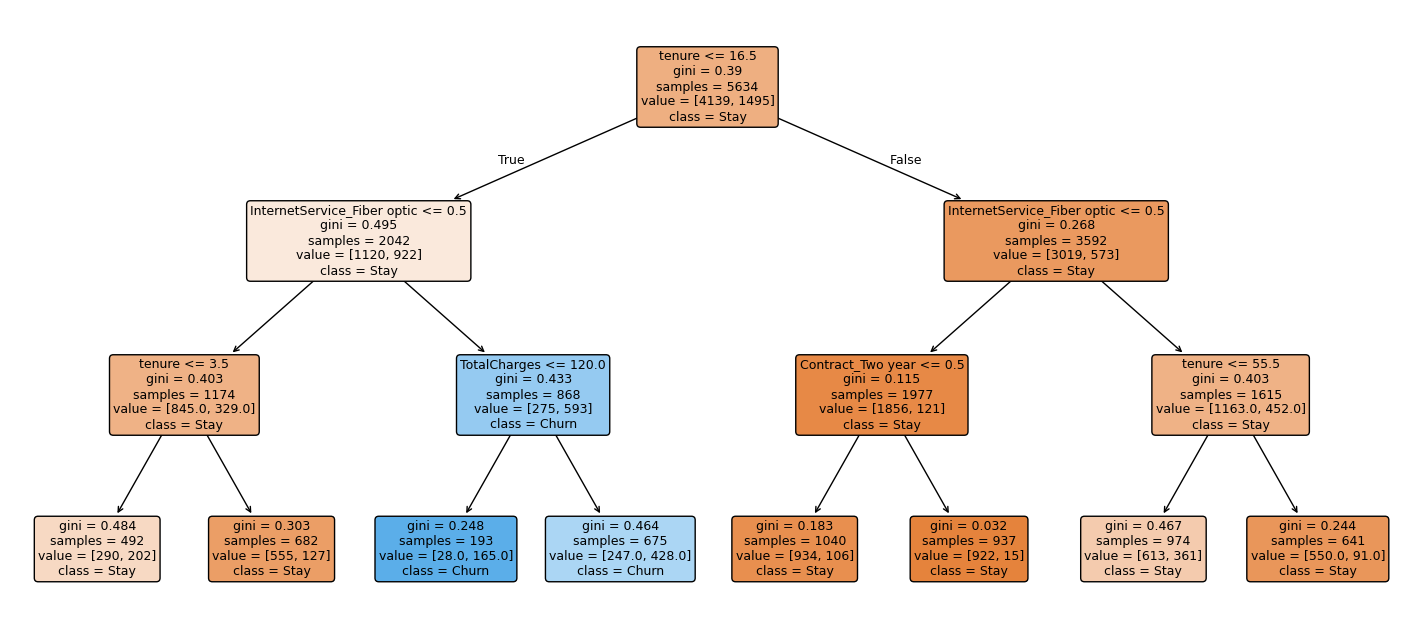

In [15]:
dt5 = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                             random_state=42).fit(X_train, y_train)
y_pred_dt = dt5.predict(X_test)
y_prob_dt = dt5.predict_proba(X_test)[:, 1]
dt3 = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
plt.figure(figsize=(18, 8))
plot_tree(dt3, feature_names=X.columns, class_names=['Stay', 'Churn'],
          filled=True, rounded=True, fontsize=9)
plt.show()

In [16]:
rf = RandomForestClassifier(n_estimators=300, max_features='sqrt',
                            min_samples_leaf=5, oob_score=True,
                            n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print(f'OOB accuracy : {rf.oob_score_:.3f}')
print(f'Test accuracy: {rf.score(X_test, y_test):.3f}')
print(f'Test AUC     : {roc_auc_score(y_test, y_prob_rf):.3f}')

OOB accuracy : 0.803
Test accuracy: 0.807
Test AUC     : 0.842


In [17]:
pi = permutation_importance(rf, X_test, y_test, scoring='roc_auc',
                            n_repeats=10, random_state=42, n_jobs=-1)
imp = pd.DataFrame({'feature': X.columns,
                    'mdi': rf.feature_importances_,
                    'permutation': pi.importances_mean})
imp = imp.sort_values('permutation', ascending=False)
print(imp.head(10).round(4).to_string(index=False))

                       feature    mdi  permutation
                        tenure 0.1912       0.0404
                  TotalCharges 0.1657       0.0206
             Contract_Two year 0.0581       0.0164
   InternetService_Fiber optic 0.0717       0.0132
             Contract_One year 0.0333       0.0059
PaymentMethod_Electronic check 0.0608       0.0031
          PaperlessBilling_Yes 0.0217       0.0014
                 SeniorCitizen 0.0120       0.0012
             MultipleLines_Yes 0.0160       0.0009
              OnlineBackup_Yes 0.0173       0.0006


In [18]:
lr_bal = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced',
                                 random_state=42))
]).fit(X_train, y_train)
y_pred_bal = lr_bal.predict(X_test)
y_prob_bal = lr_bal.predict_proba(X_test)[:, 1]
for name, pred in [('LR default', y_pred_lr), ('LR balanced', y_pred_bal)]:
    print(f'{name:12s} P={precision_score(y_test, pred):.3f}  '
          f'R={recall_score(y_test, pred):.3f}  '
          f'F1={f1_score(y_test, pred):.3f}')

LR default   P=0.658  R=0.567  F1=0.609
LR balanced  P=0.505  R=0.781  F1=0.613


In [19]:
df2 = df.copy()
svc = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies']
df2['n_services'] = (df2[svc] == 'Yes').sum(axis=1)
df2['is_new'] = (df2['tenure'] <= 12).astype(int)
df2['charge_per_mo'] = df2['TotalCharges'] / df2['tenure'].clip(lower=1)
df2['price_jump'] = df2['MonthlyCharges'] - df2['charge_per_mo']
X2 = build_features(df2)
X2_train, X2_test = X2.loc[X_train.index], X2.loc[X_test.index]  # same split
rf2 = RandomForestClassifier(n_estimators=300, max_features='sqrt',
                             min_samples_leaf=5, n_jobs=-1, random_state=42)
rf2.fit(X2_train, y_train)
y_prob_rf2 = rf2.predict_proba(X2_test)[:, 1]
print(f'RF AUC before: {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'RF AUC after : {roc_auc_score(y_test, y_prob_rf2):.4f}')

RF AUC before: 0.8422
RF AUC after : 0.8420


In [20]:

def evaluate(name, pred, prob):
    return {'model': name,
            'accuracy': accuracy_score(y_test, pred),
            'precision': precision_score(y_test, pred, zero_division=0),
            'recall': recall_score(y_test, pred),
            'f1': f1_score(y_test, pred),
            'auc': roc_auc_score(y_test, prob)}
results = pd.DataFrame([
    evaluate('Baseline', dummy.predict(X_test),
             dummy.predict_proba(X_test)[:, 1]),
    evaluate('Logistic Regression', y_pred_lr, y_prob_lr),
    evaluate('LR balanced', y_pred_bal, y_prob_bal),
    evaluate('Decision Tree (d=5)', y_pred_dt, y_prob_dt),
    evaluate('Random Forest', y_pred_rf, y_prob_rf),
]).round(3)
print(results.to_string(index=False))

              model  accuracy  precision  recall    f1   auc
           Baseline     0.735      0.000   0.000 0.000 0.500
Logistic Regression     0.807      0.658   0.567 0.609 0.842
        LR balanced     0.739      0.505   0.781 0.613 0.841
Decision Tree (d=5)     0.796      0.632   0.551 0.589 0.829
      Random Forest     0.807      0.673   0.529 0.593 0.842


# Analysis of Telco Customer Churn Lab

## Objective
The main objective of this lab is to analyze the **Telco Customer Churn dataset** and build machine learning models to predict whether a customer will **churn (leave the service)** or **stay**.

## Dataset and Preprocessing
- The dataset contains **7,043 customers and 21 columns**.
- `TotalCharges` was converted from text to numeric values.
- Missing values in `TotalCharges` were replaced with the median.
- The `customerID` column was removed.
- Categorical variables were converted into numerical variables using **one-hot encoding**.
- The final feature set contained **30 features**.
- The data was divided into:
  - **80% training data:** 5,634 samples
  - **20% testing data:** 1,409 samples
- Stratified splitting was used to maintain the same churn ratio in both sets.

## Baseline Model
A `DummyClassifier` was used as a baseline model.

- Baseline Accuracy: **73.5%**

This provides a simple reference point for evaluating the machine learning models.

## Logistic Regression
A Logistic Regression model was trained using feature standardization.

Results:
- Accuracy: **80.7%**
- Precision: **65.8%**
- Recall: **56.7%**
- F1-score: **60.9%**
- ROC-AUC: **0.842**

The Logistic Regression coefficients were also analyzed to identify important features related to customer churn.

### Important Features
Features associated with lower churn included:
- Tenure
- MonthlyCharges
- One-year contract
- Two-year contract
- OnlineSecurity

Features associated with higher churn included:
- Fiber optic internet service
- TotalCharges
- StreamingMovies
- StreamingTV
- MultipleLines

## Confusion Matrix
The confusion matrix for Logistic Regression was calculated:

- True Negative (TN): **925**
- False Positive (FP): **110**
- False Negative (FN): **162**
- True Positive (TP): **212**

Precision, recall, and F1-score were also calculated manually and compared with the values produced by Scikit-learn.

## Random Forest
A Random Forest classifier with **300 trees** was trained.

Results:
- OOB Accuracy: **80.3%**
- Test Accuracy: **80.7%**
- ROC-AUC: **0.842**

Permutation importance was also used to identify influential features.

The most important features included:
- Tenure
- TotalCharges
- Two-year contract
- Fiber optic internet service
- One-year contract

## Class Imbalance Analysis
A balanced Logistic Regression model was trained using `class_weight='balanced'`.

Comparison:

| Model | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Logistic Regression | 0.658 | 0.567 | 0.609 |
| Balanced Logistic Regression | 0.505 | 0.781 | 0.613 |

The balanced model increased **recall**, meaning it detected more churn customers, but its **precision decreased**.

## Feature Engineering
Additional features were created, including:

- Number of services
- New customer indicator
- Charge per month
- Price jump

The Random Forest AUC was compared before and after feature engineering:

- Before: **0.8422**
- After: **0.8420**

The additional features therefore produced almost no improvement in the model's AUC.

## Model Comparison

| Model | Accuracy | Precision | Recall | F1 | AUC |
|---|---:|---:|---:|---:|---:|
| Baseline | 0.735 | 0.000 | 0.000 | 0.000 | 0.500 |
| Logistic Regression | 0.807 | 0.658 | 0.567 | 0.609 | 0.842 |
| Balanced Logistic Regression | 0.739 | 0.505 | 0.781 | 0.613 | 0.841 |
| Decision Tree (depth=5) | 0.796 | 0.632 | 0.551 | 0.589 | 0.829 |
| Random Forest | 0.807 | 0.673 | 0.529 | 0.593 | 0.842 |

## Overall Analysis
This lab demonstrates the complete process of **customer churn prediction**, including data preprocessing, feature encoding, train-test splitting, baseline modeling, Logistic Regression, Decision Tree, Random Forest, confusion matrix analysis, class imbalance handling, feature importance, and feature engineering.

The Logistic Regression and Random Forest models achieved approximately **80.7% accuracy** and **0.842 ROC-AUC**. The analysis also shows that changing the class weights can increase churn recall, while the additional engineered features used in the lab did not significantly improve the Random Forest AUC.